# 확률보행 연습

In [2]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 3.5.1 확률보행 시뮬레이션 & 예측

In [3]:
# 500개 단계의 확률보행 생성
np.random.seed(40)

steps = np.random.standard_normal(500)
steps[0] = 10

random_walk = np.cumsum(steps)

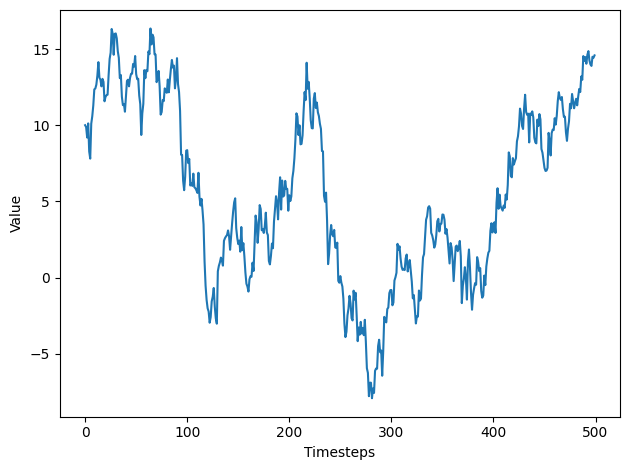

In [4]:
#Random Walk Figure
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

In [5]:
# Stationary Check

adf_result = adfuller(random_walk)

print(f'ADF Stats: {adf_result[0]}')
print(f'ADF P-Val: {adf_result[1]}')

ADF Stats: -1.5913356419504012
ADF P-Val: 0.4879444456632103


**ADF stats 볼 때, Critical Value(1%: -3.5; 5%: -2.9; 10%: -2.6)보다 덜 음수면 귀무가설 기각 불가**

해석:
- 수치를 봤을 때, 이 시계열은 비정상성을 띔.

In [6]:
# First Differencing

diff_random_walk = np.diff(random_walk, n=1)

In [7]:
# Stationary Check after 1st diff

adf_result = adfuller(diff_random_walk)

print(f'ADF Stats: {adf_result[0]}')
print(f'ADF P-Val: {adf_result[1]}')

ADF Stats: -21.97352511752582
ADF P-Val: 0.0


Interpretation:
- Can reject the Null

In [10]:
# Grab first 400 as the train set; remaining 100 as test set

df = pd.DataFrame({'value': random_walk})

train = df[:400] #0~399: count 400
test = df[400:]

In [ ]:
# 1. Predict with the Mean
mean = np.mean(train.value)

test.loc[:, 'pred_mean'] = mean
test.head()

,value,pred_mean
400,3.535928,4.571965
401,3.627021,4.571965
402,2.928230,4.571965
403,4.910073,4.571965
404,5.861157,4.571965


In [14]:
# 2. Predict with the last known value
last_val = train.iloc[-1].value

test.loc[:, 'pred_last'] = last_val

test.head()

,value,pred_mean,pred_last
400,3.535928,4.571965,2.960159
401,3.627021,4.571965,2.960159
402,2.928230,4.571965,2.960159
403,4.910073,4.571965,2.960159
404,5.861157,4.571965,2.960159


In [ ]:
# 3. Predict with drift
# Reminder: 
# - 단순법에 추세를 더한방법. 마지막 값을 반복하는 것이 아닌, 과거의 평균적인 변화량(증가 or 감소)추세 만큼 계속 더해가면서 예측
# - With random walk: 'c' is based on the past data's trend; then predict the future
# Equation: deltaY / deltaX

deltaX = 400-0 # why -0? --> x_i = starting point's timestep index = 0
deltaY = last_val - 10 # why 10? --> steps[0] is set 10; 

drift = deltaY / deltaX

x_vals = np.arange(400, 500, 1)

pred_drift = drift * x_vals + 10

test.loc[:, 'pred_drift'] = pred_drift

test.head()

,value,pred_mean,pred_last,pred_drift
400,3.535928,4.571965,2.960159,2.960159
401,3.627021,4.571965,2.960159,2.942559
402,2.928230,4.571965,2.960159,2.924960
403,4.910073,4.571965,2.960159,2.907360
404,5.861157,4.571965,2.960159,2.889760


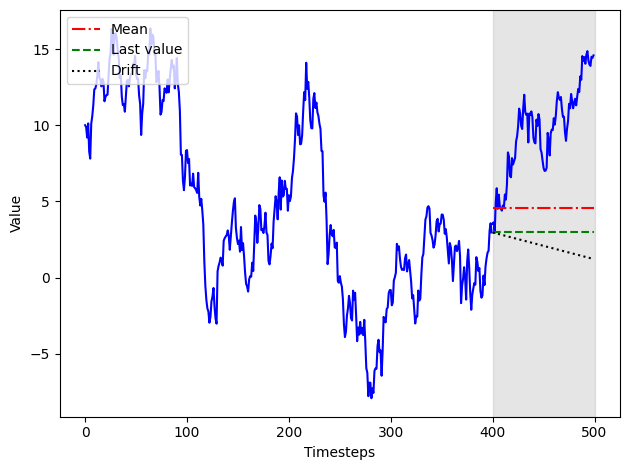

In [17]:
fig, ax = plt.subplots()

ax.plot(train['value'], 'b-')
ax.plot(test['value'], 'b-')
ax.plot(test['pred_mean'], 'r-.', label='Mean')
ax.plot(test['pred_last'], 'g--', label='Last value')
ax.plot(test['pred_drift'], 'k:', label='Drift')

ax.axvspan(400, 500, color='#808080', alpha=0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

In [18]:
# which one has the lowest MSE?

from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last'])
mse_drift = mean_squared_error(test['value'], test['pred_drift'])

print(mse_mean, mse_last, mse_drift)

34.90129556985135 54.07514083616252 69.38118694822901


MSE_MEAN has the lowest MSE;
Relative to the data, this number is big.
RMSE ~= 5.9

In [20]:
# Forecast the next timestep

df_shift = df.shift(periods = 1)

mse_one_step = mean_squared_error(test['value'], df_shift[400:])

mse_one_step

0.670898152293387

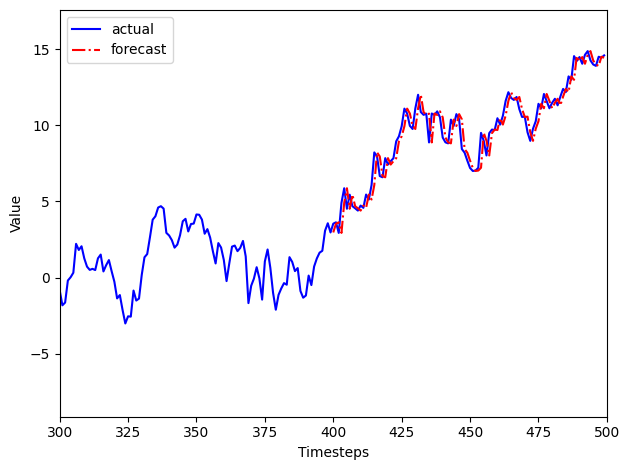

In [21]:
fig, ax = plt.subplots()

ax.plot(df, 'b-', label='actual')
ax.plot(df_shift[400:], 'r-.', label='forecast')

ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.xlim(300, 500)
plt.tight_layout()